Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt50Ru50 KOH CO oxidation<br>

In [1]:
from setup import *

# LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.58,7
,3000,0,0.55,15
,3000,0,0.57,7
,3000,0,0.60,15


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 615 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -974.69    77.57
p_loo       35.94        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      613   99.7%
   (0.70, 1]   (bad)         1    0.2%
   (1, Inf)   (very bad)    1    0.2%



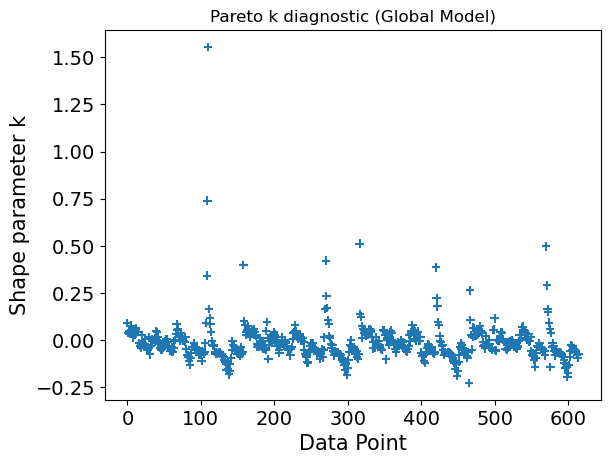

In [2]:
with pm.Model() as LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in) 
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + log_theta_CO + log_theta_OH 
    log_rate = observables(log_rate_model) 

trace_LH_2, loo_LH_2 = fit_and_evaluate(LH_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.087  0.001  -0.088   -0.085      0.000    0.000    2228.0    2427.0    1.0
deltaG4_0 -0.103  0.001  -0.105   -0.101      0.000    0.000    2174.0    2620.0    1.0
Gact2_0    0.617  0.001   0.614    0.619      0.000    0.000    1646.0    2198.0    1.0
sigma_rel  1.568  0.078   1.427    1.715      0.002    0.001    1689.0    1937.0    1.0


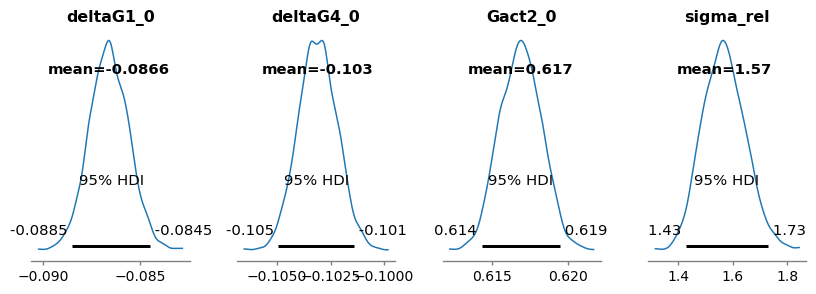

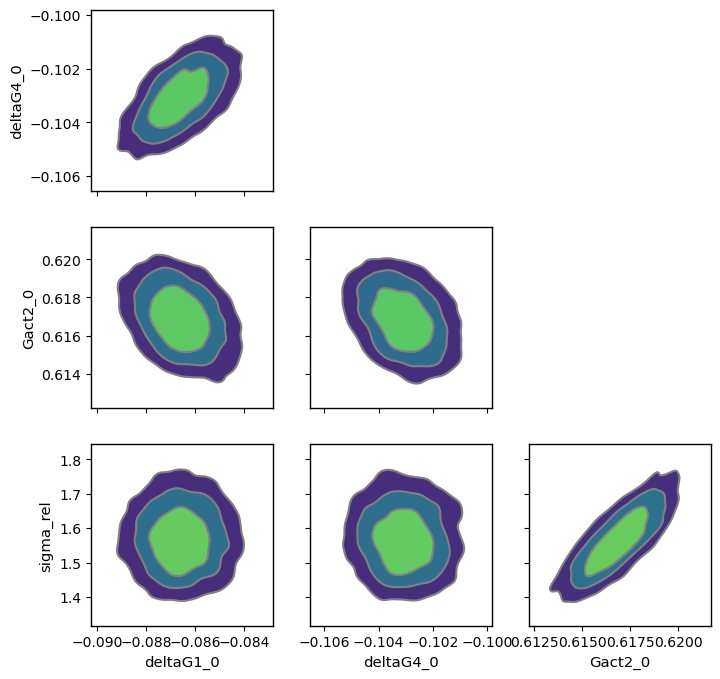

Sampling: [rate]


rate: 0.502


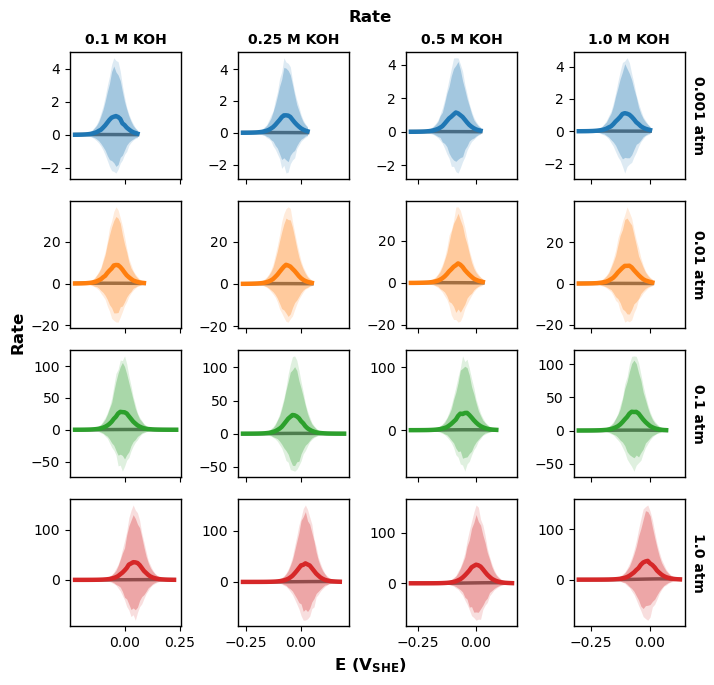

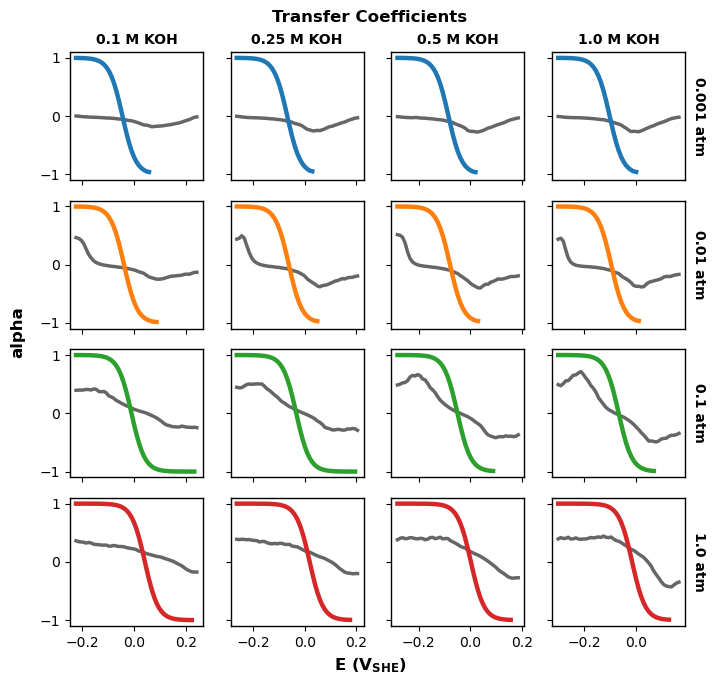

TypeError: 'function' object is not subscriptable

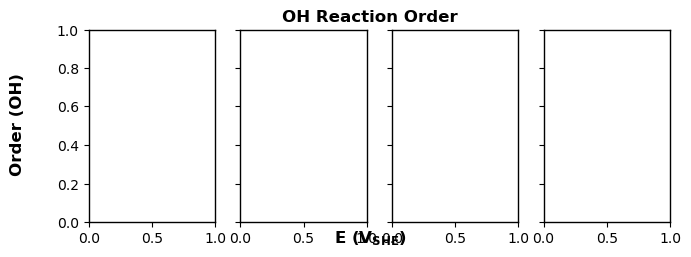

In [3]:
ppc_LH_2 = plot_posteriors(trace_LH_2, LH_2, plot_target)
plot_model_fits(trace_LH_2, ppc_LH_2); plot_coverages(trace_LH_2)

# ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.47,7
,3000,0,0.44,7
,3000,0,0.43,7
,3000,0,0.49,15


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 575 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -10806.72  1274.51
p_loo      494.62        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      549   95.5%
   (0.70, 1]   (bad)         9    1.6%
   (1, Inf)   (very bad)   17    3.0%



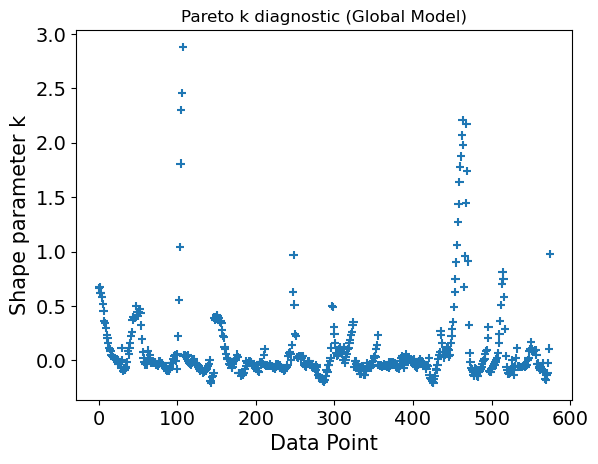

In [6]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + log_theta_CO + np.log(C_KOH_in)
    log_rate = observables(log_rate_model) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.118  0.000  -0.118   -0.117        0.0      0.0    1617.0    1739.0    1.0
deltaG4_0  0.011  0.003   0.006    0.016        0.0      0.0    1128.0    1545.0    1.0
Gact2_0    0.749  0.000   0.749    0.750        0.0      0.0    1266.0    1782.0    1.0
beta_2     0.263  0.002   0.260    0.266        0.0      0.0    1045.0    1473.0    1.0


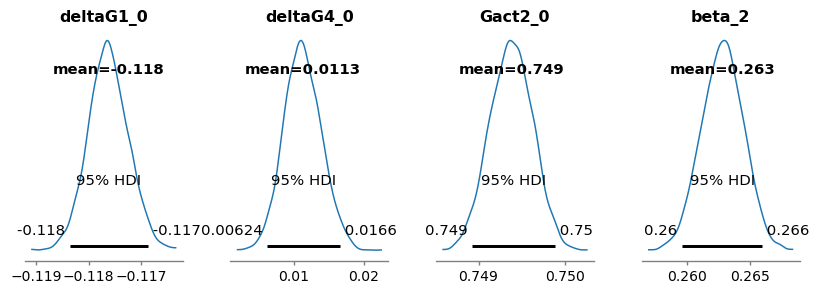

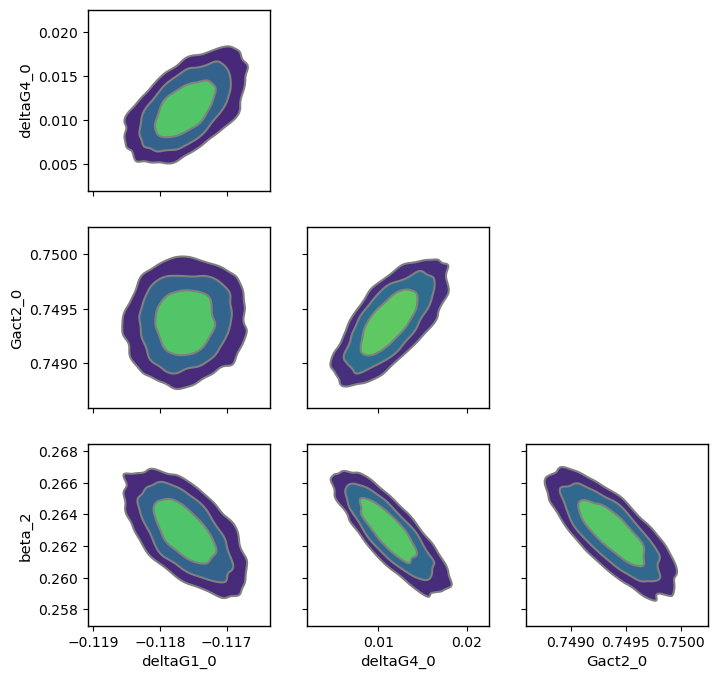

Sampling: [rate]


rate: 0.865


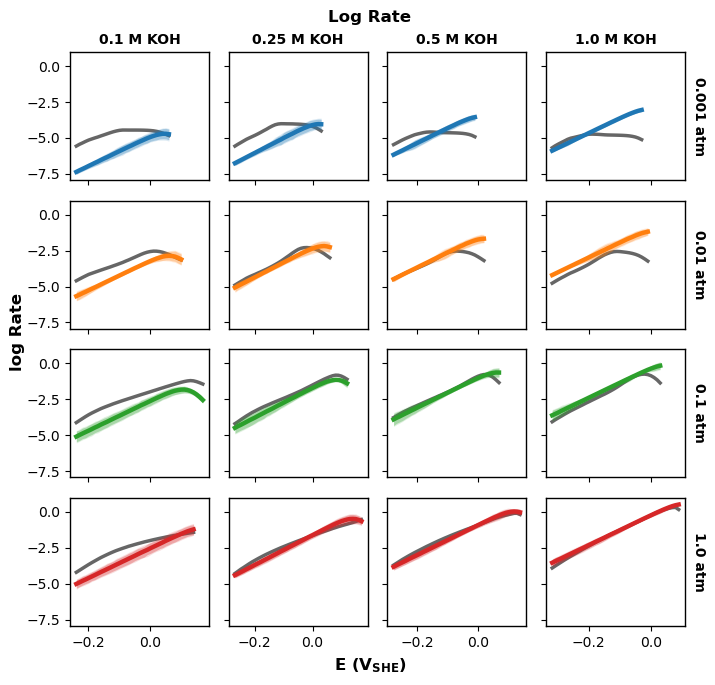

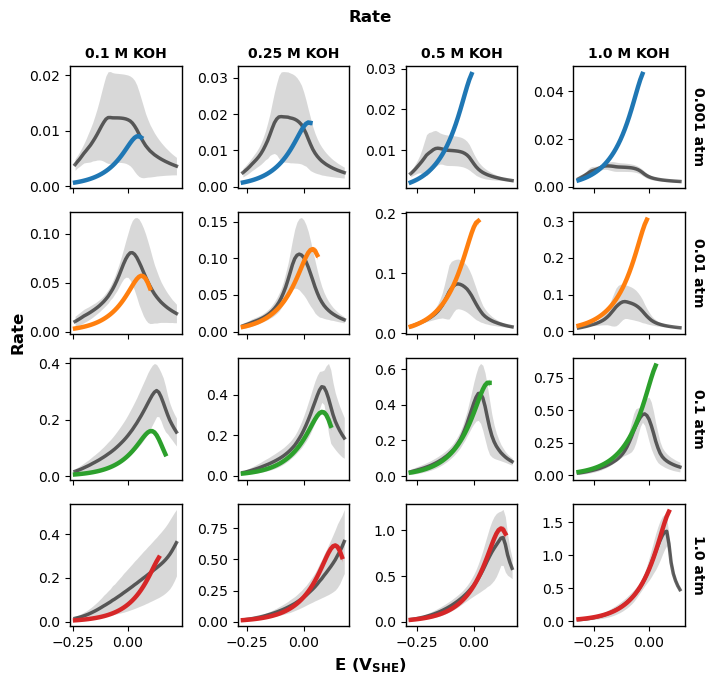

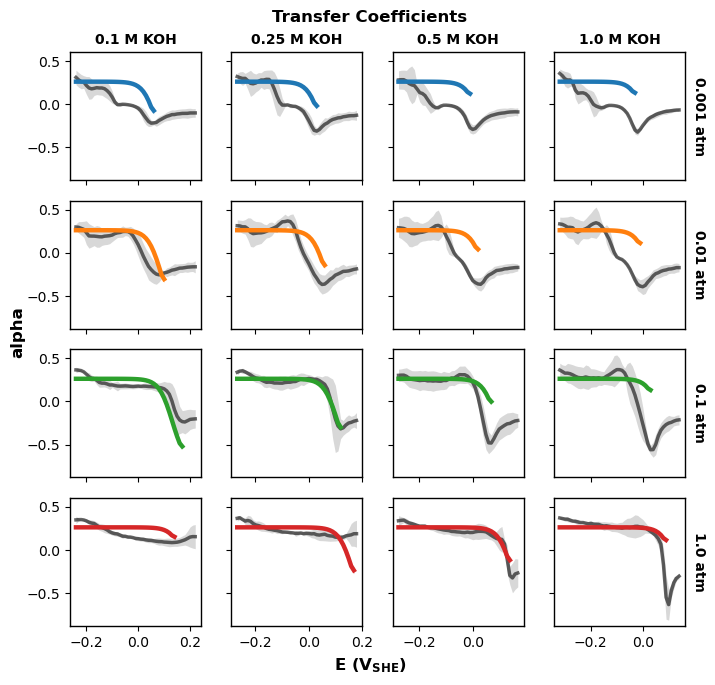

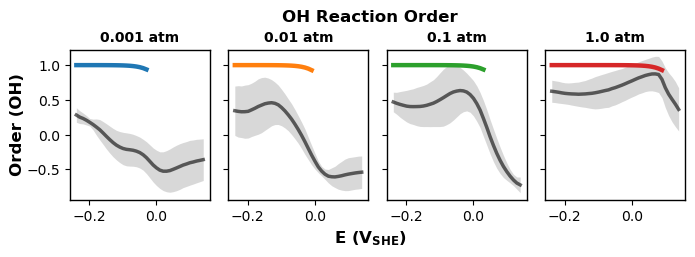

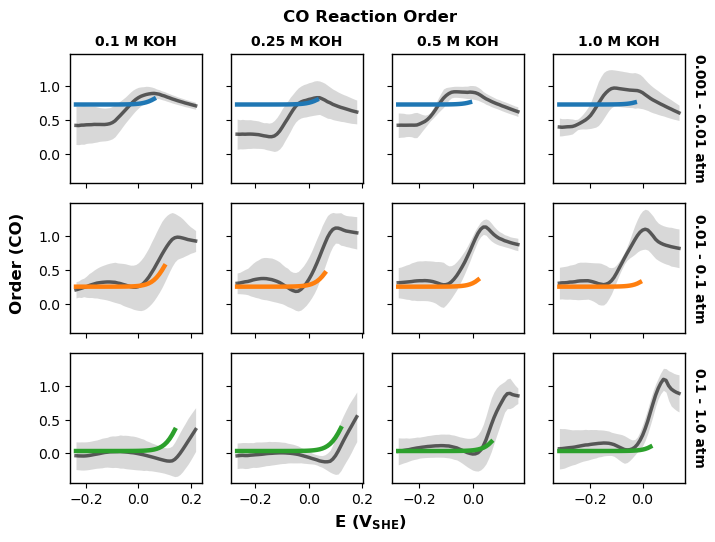

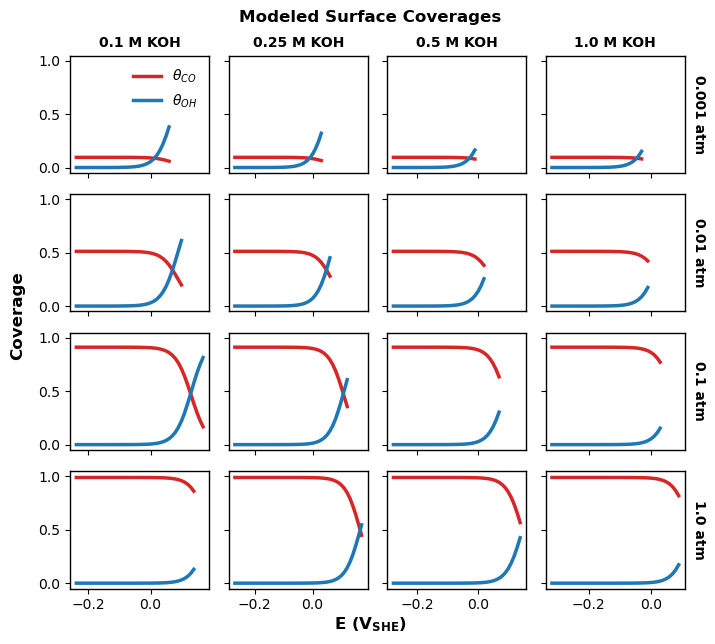

In [7]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2, plot_target)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)

# LH 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.05,95
,3000,0,0.06,63
,3000,0,0.07,7
,3000,0,0.05,31


Computed from 4000 posterior samples and 575 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -10447.35  1165.21
p_loo      303.47        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      560   97.4%
   (0.70, 1]   (bad)         6    1.0%
   (1, Inf)   (very bad)    9    1.6%



c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


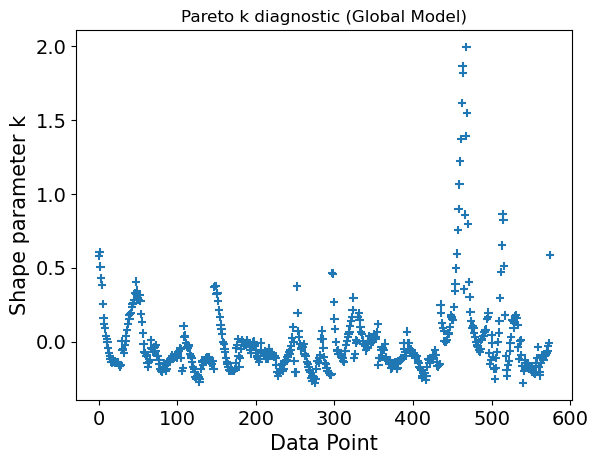

In [8]:
with pm.Model() as LH_3:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* <-> COOH* + * (QEA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0.0, sigma=0.2) 
    beta_3 = pm.Beta('beta_3', alpha=5, beta=5)   
    Gact3_0 = pm.Normal('Gact3_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2 = deltaG2_0 
    deltaG4 = deltaG4_0 - E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in) 
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_K2 + term_CO + term_OH
    zeros = pt.zeros_like(term_COOH)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_LH_3, loo_LH_3 = fit_and_evaluate(LH_3)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.346  0.050  -0.433   -0.267      0.003    0.003     281.0     246.0   1.01
deltaG4_0 -0.525  0.050  -0.612   -0.447      0.003    0.003     281.0     246.0   1.01
deltaG2_0  0.233  0.050   0.156    0.322      0.003    0.003     281.0     243.0   1.01
Gact3_0    0.752  0.000   0.752    0.752      0.000    0.000    2251.0    2068.0   1.00
beta_3     0.223  0.001   0.221    0.226      0.000    0.000    2309.0    2050.0   1.00


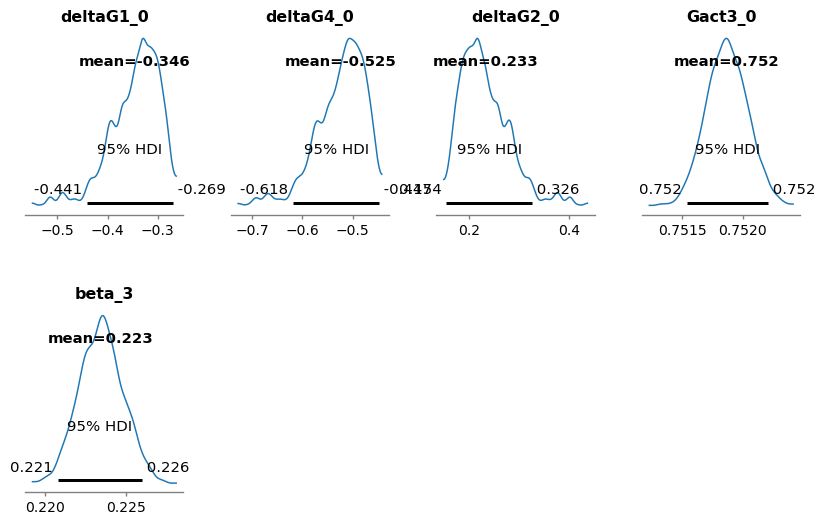

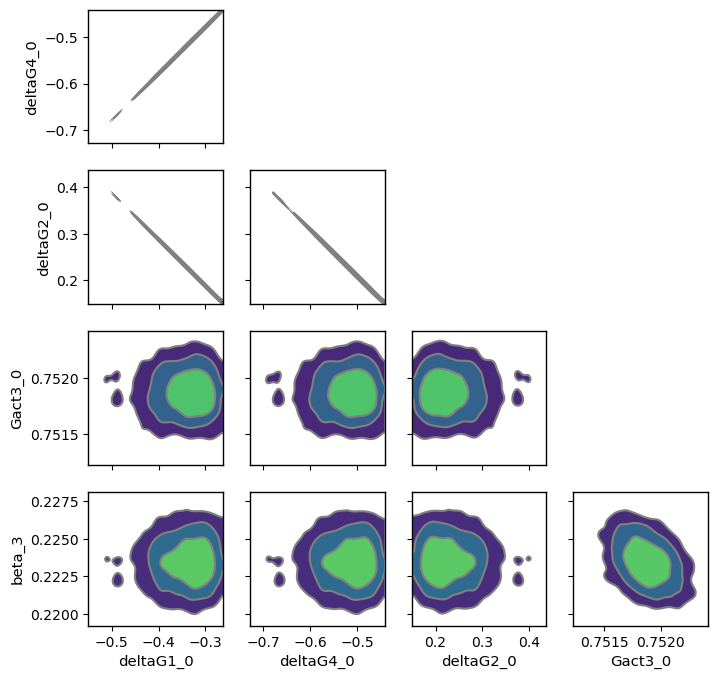

Sampling: [rate]


rate: 0.865


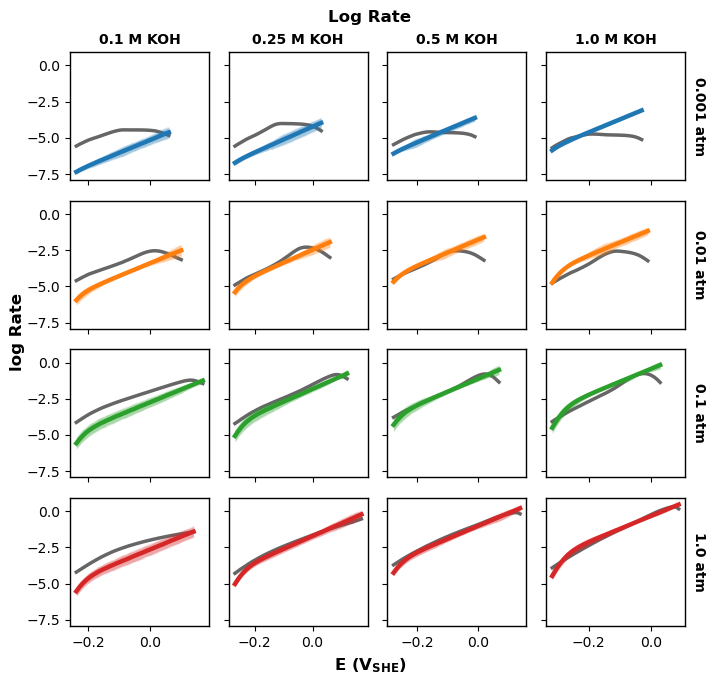

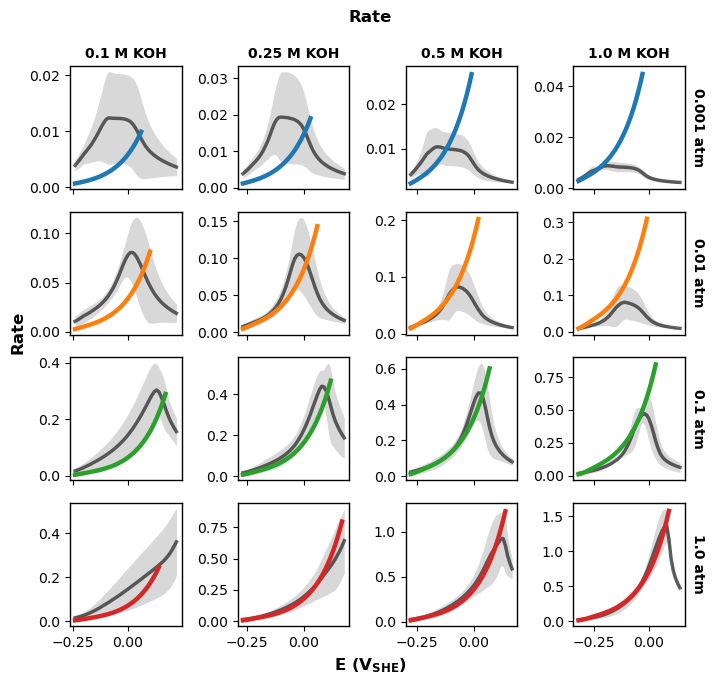

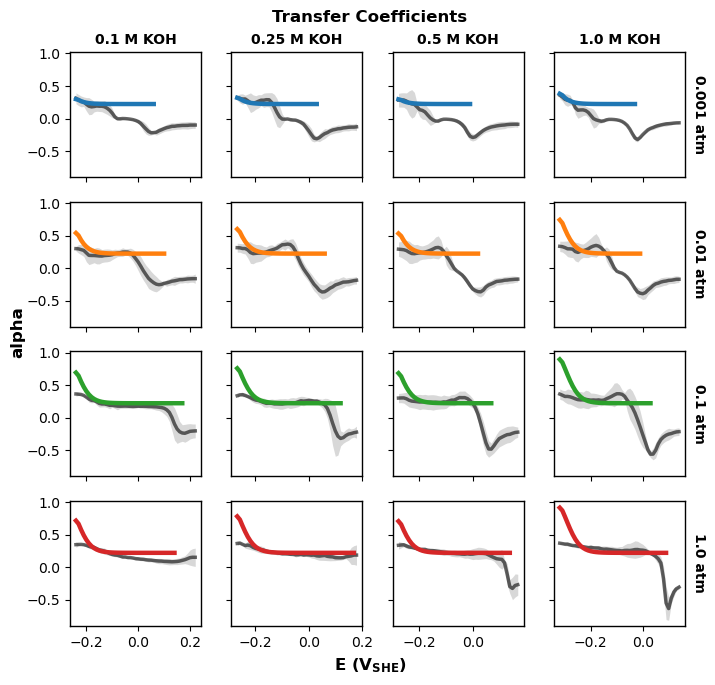

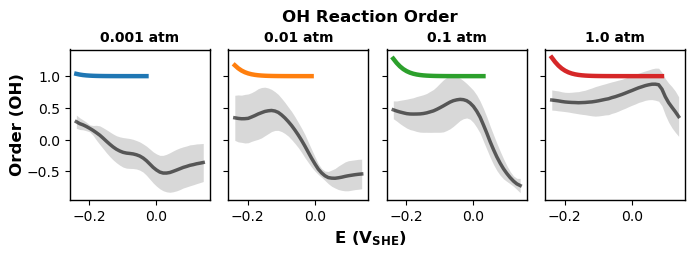

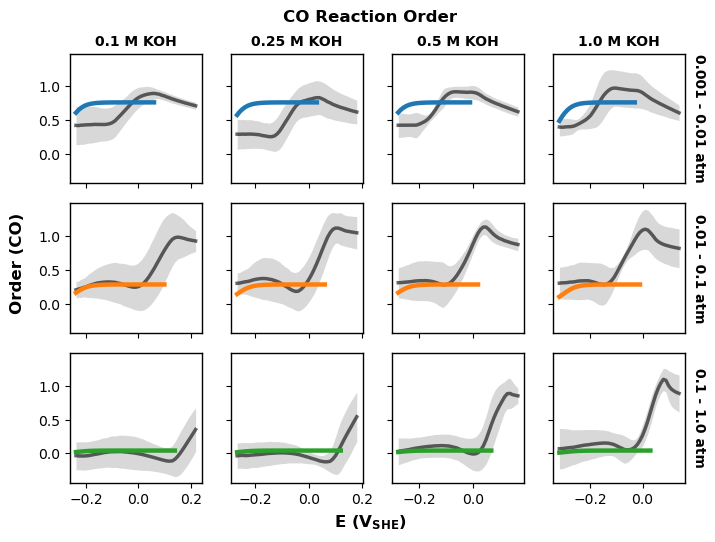

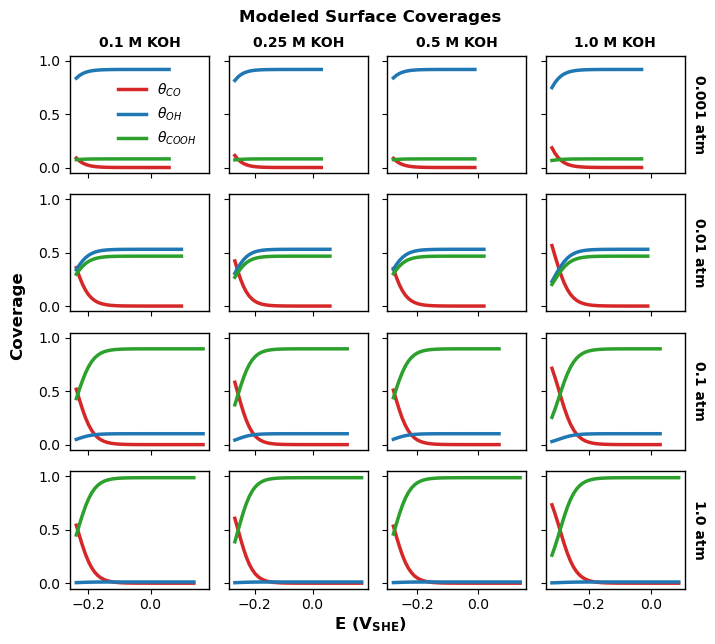

In [9]:
ppc_LH_3 = plot_posteriors(trace_LH_3, LH_3, plot_target)
plot_model_fits(trace_LH_3, ppc_LH_3); plot_coverages(trace_LH_3)

# ER 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.05,31
,3000,0,0.05,167
,3000,0,0.07,127
,3000,0,0.05,1023


Computed from 4000 posterior samples and 575 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -10444.82  1165.17
p_loo      309.04        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      557   96.9%
   (0.70, 1]   (bad)         7    1.2%
   (1, Inf)   (very bad)   11    1.9%



c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


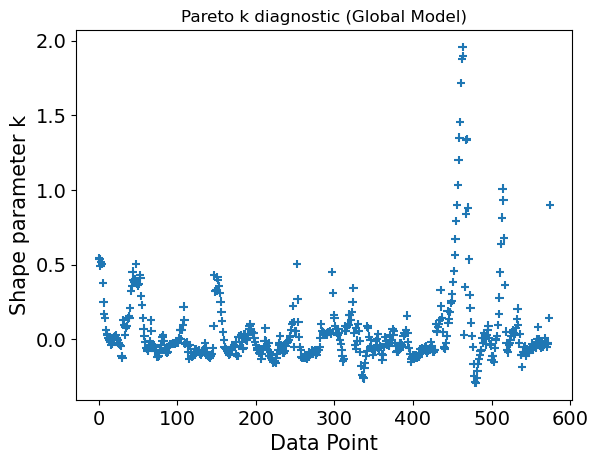

In [10]:
with pm.Model() as ER_3:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- <-> COOH* + (e-) (QEA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_3 = pm.Beta('beta_3', alpha=5, beta=5)
    Gact3_0 = pm.Normal('Gact3_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2 = deltaG2_0 - E_in
    deltaG4 = deltaG4_0 - E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_K2 + term_CO + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_COOH)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_ER_3, loo_ER_3 = fit_and_evaluate(ER_3)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.361  0.058  -0.456   -0.271      0.003    0.004     330.0     567.0   1.02
deltaG4_0 -0.540  0.058  -0.633   -0.449      0.003    0.004     329.0     562.0   1.02
deltaG2_0 -0.292  0.001  -0.294   -0.290      0.000    0.000    2152.0    1985.0   1.00
Gact3_0    0.752  0.000   0.752    0.752      0.000    0.000    3247.0    2693.0   1.00
beta_3     0.223  0.001   0.221    0.226      0.000    0.000    2630.0    2364.0   1.00


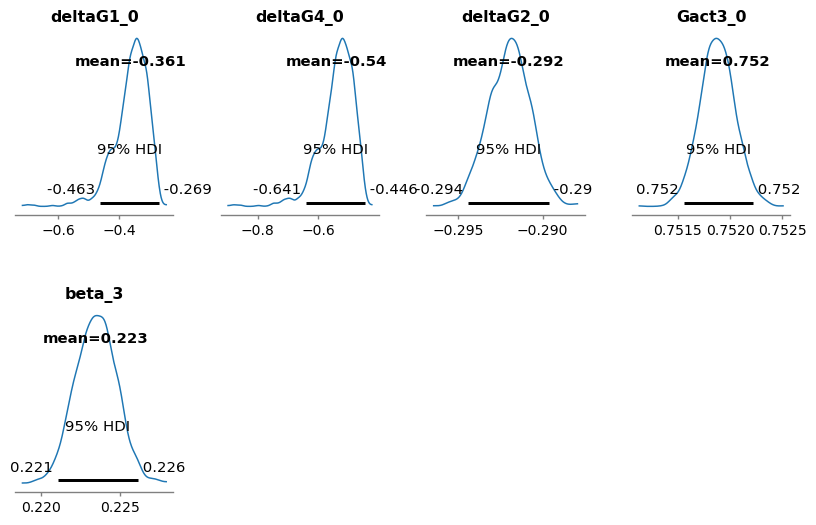

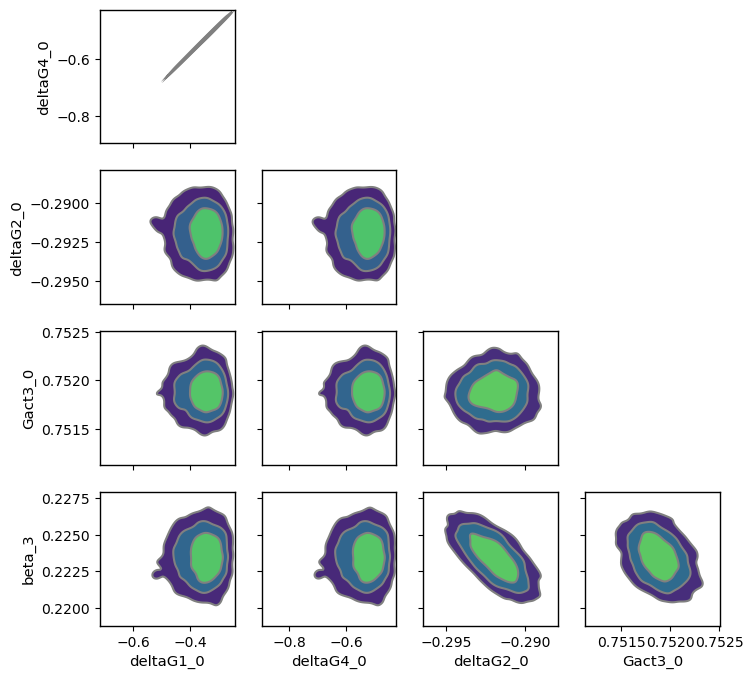

Sampling: [rate]


rate: 0.865


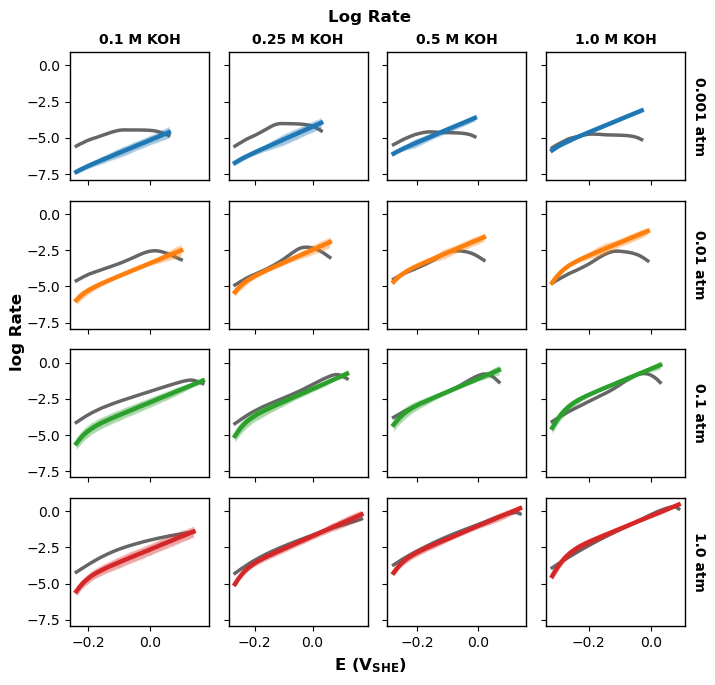

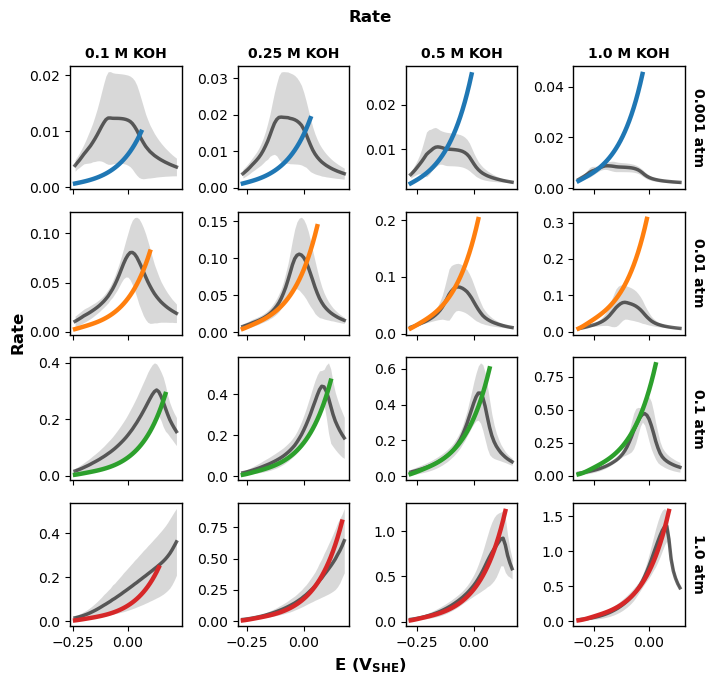

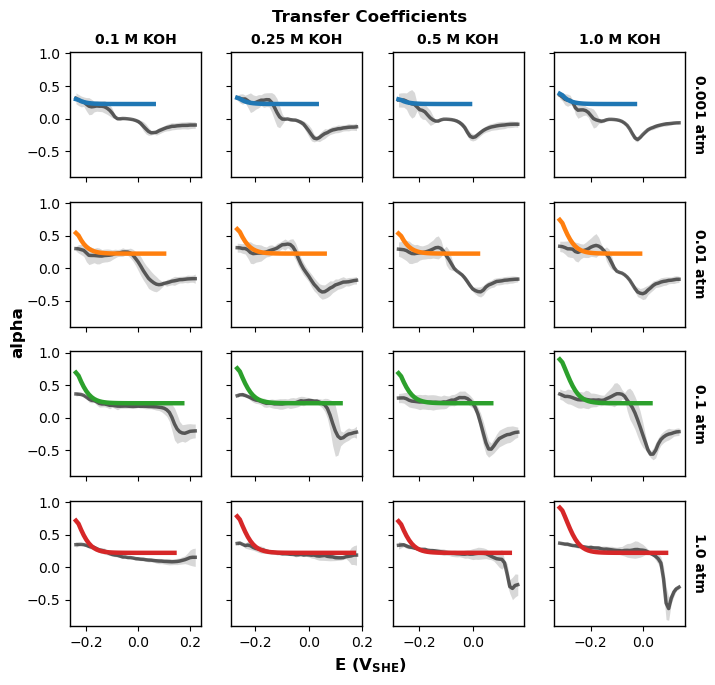

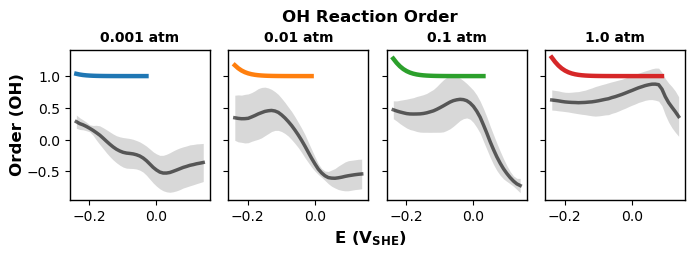

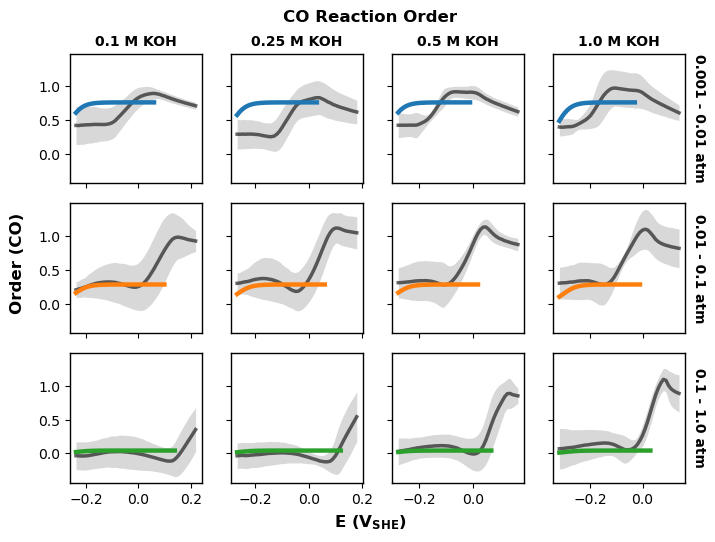

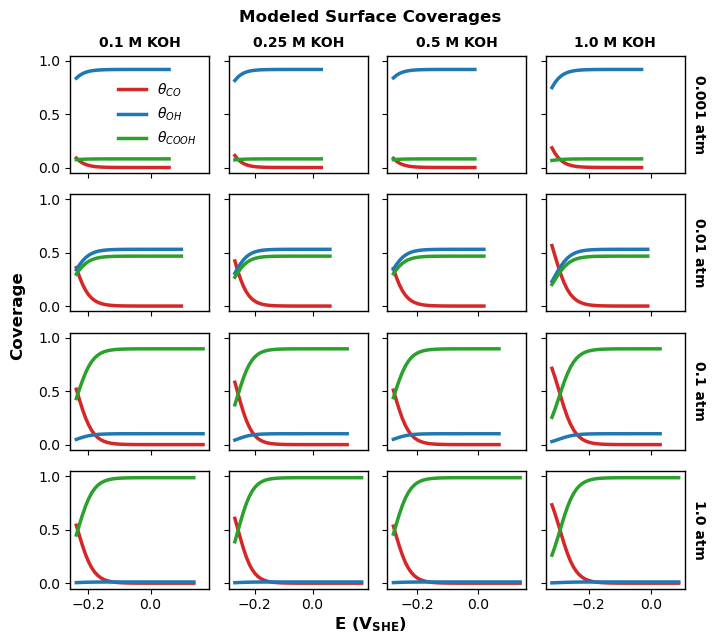

In [11]:
ppc_ER_3 = plot_posteriors(trace_ER_3, ER_3, plot_target)
plot_model_fits(trace_ER_3, ppc_ER_3); plot_coverages(trace_ER_3)

# Comparison

      rank      elpd_loo        p_loo     elpd_diff    weight           se          dse  warning scale
ER_3     0 -10444.815963   309.042273      0.000000  0.296297  1165.169791     0.000000     True   log
LH_3     1 -10447.348294   303.470712      2.532331  0.042003  1165.214557     3.943073     True   log
ER_2     2 -10806.720051   494.618544    361.904088  0.517576  1274.507862   260.754696     True   log
LH_2     3 -88753.303834  1860.103426  78308.487871  0.144125  6955.040892  6945.245440     True   log


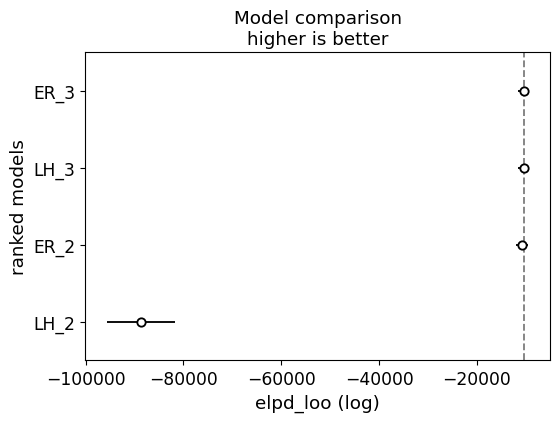

In [ ]:
comparison_dict = {
    "LH_2": loo_LH_2,
    "ER_2": loo_ER_2,
    "LH_3": loo_LH_3,
    "ER_3": loo_ER_3,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()

In [15]:
# Collision theory comparison
m_CO = 28.01e-3 / 6.022e23 # Mass of CO molecule in kg
P_atm_to_Pa = 101325 # 1 atm to Pa
A_site = F * 1e-4 / (210e-6 * 6.022e23) # Surface area of a single Pt site
sticking_probability = 0.8
k1f = sticking_probability * P_atm_to_Pa*A_site /np.sqrt(2*np.pi*m_CO*kb_J*T)

print(f'CO adsorption rate constant (Collision theory): {k1f:.3e} s^-1') # Too high - just use QEA instead 

CO adsorption rate constant (Collision theory): 1.798e+08 s^-1
